In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('klang_valley_rentals.csv')

In [28]:
df.isna().sum()

listing_id         0
location           0
property_type      0
rooms             24
bathrooms        105
car_parks        271
size_sqft         36
furnished         57
monthly_rent       0
date_listed        0
agent_rating     128
dtype: int64

In [29]:
((df.isna().sum()/len(df))*100).round(2)

listing_id        0.00
location          0.00
property_type     0.00
rooms             1.94
bathrooms         8.48
car_parks        21.89
size_sqft         2.91
furnished         4.60
monthly_rent      0.00
date_listed       0.00
agent_rating     10.34
dtype: float64

In [30]:
df.columns

Index(['listing_id', 'location', 'property_type', 'rooms', 'bathrooms',
       'car_parks', 'size_sqft', 'furnished', 'monthly_rent', 'date_listed',
       'agent_rating'],
      dtype='object')

In [31]:
df.duplicated().sum()

np.int64(38)

In [32]:
df.car_parks.unique()

array([ 2.,  0., nan,  1.,  3.])

In [33]:
df[df.duplicated()]

,listing_id,location,property_type,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating
209,KV100663,Ampang,Apartment,3.0,NaN,NaN,790 sq. ft.,Fully Furnished,"RM 2,450",06/03/2026,4.1
324,KV100199,Setapak,Condominium,4.0,4.0,1.0,720 sq. ft.,Partially Furnished,"RM 1,500",2025-03-31,3.5
375,KV100674,Shah Alam,Condominium,3.0,3.0,2.0,"1,180 sq. ft.",not furnished,"RM 2,500",2026-03-07,5.0
478,KV100361,Kajang,Condominium,4.0,3.0,1.0,670 sq. ft.,NOT FURNISHED,"RM 1,150",2026-04-18,3.7
495,KV100610,Kajang,Serviced Residence,3.0,2.0,2.0,480 sq. ft.,FULLY FURNISHED,"RM 1,050",2025-05-03,3.9
531,KV101082,Puchong,Condominium,2.0,1.0,1.0,"1,710 sq. ft.",Not Furnished,"RM 2,750",2026-01-31,4.1
535,KV100815,Subang Jaya,Apartment,2.0,2.0,NaN,890 sq. ft.,Fully Furnished,"RM 2,350",2026-04-14,3.3
542,KV100442,Setapak,Apartment,2.0,2.0,2.0,950 sq. ft.,Fully Furnished,"RM 1,900",2026-07-31,4.7
559,KV100558,Cheras,Serviced Residence,2.0,NaN,1.0,870 sq. ft.,Fully Furnished,"RM 2,100",24/01/2026,NaN
586,KV100105,Petaling Jaya,Condominium,3.0,2.0,2.0,"1,400 sq. ft.",partially furnished,"RM 3,300",19/07/2026,4.4


## A1 initial Data Analysis (Data Audit)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     1238 non-null   object 
 1   location       1238 non-null   object 
 2   property_type  1238 non-null   object 
 3   rooms          1214 non-null   float64
 4   bathrooms      1133 non-null   float64
 5   car_parks      967 non-null    float64
 6   size_sqft      1202 non-null   object 
 7   furnished      1181 non-null   object 
 8   monthly_rent   1238 non-null   object 
 9   date_listed    1238 non-null   object 
 10  agent_rating   1110 non-null   float64
dtypes: float64(4), object(7)
memory usage: 106.5+ KB


In [23]:
df.describe()

,rooms,bathrooms,car_parks,agent_rating
count,1214.000000,1133.000000,967.000000,1110.000000
mean,3.464580,2.368932,1.513961,4.015946
std,6.815189,1.034641,0.907504,0.616315
min,0.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.625000
50%,3.000000,2.000000,2.000000,4.000000
75%,4.000000,3.000000,2.000000,4.400000
max,99.000000,5.000000,3.000000,7.000000


In [24]:
df.head()

,listing_id,location,property_type,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating
0,KV100369,Mont Kiara,Condominium,4.0,4.0,2.0,"1,000 sq. ft.",Partly Furnished,"RM 4,350",08/05/2026,4.2
1,KV100283,Setapak,Serviced Residence,3.0,2.0,0.0,"1,090 sq. ft.",Partially Furnished,"RM 2,200",2025-10-29,3.4
2,KV100051,AMPANG,Serviced Residence,4.0,3.0,NaN,950 sq. ft.,Partially Furnished,"RM 2,800",04/05/2026,3.4
3,KV100409,Subang Jaya,Condominium,2.0,1.0,2.0,850 sq. ft.,Partly Furnished,"RM 2,200",2025-04-24,4.0
4,KV100766,PUCHONG,Condominium,3.0,2.0,2.0,830 sq. ft.,Partially Furnished,"RM 1,700",2025-08-05,3.6


## Step 3 Missing Value count + percentage

In [41]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum()/ len (df))*100

missing_report =pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct':missing_pct.round(2)
})
missing_report = missing_report [missing_report['missing_count'] >0]
print(missing_report)

              missing_count  missing_pct
rooms                    24         1.94
bathrooms               105         8.48
car_parks               271        21.89
size_sqft                36         2.91
furnished                57         4.60
agent_rating            128        10.34


## Step 4 Duplicate Record

In [44]:
dup_count = df.duplicated().sum()
print(f"Duplicated Record {dup_count}")

Duplicated Record 38


In [45]:
df[df.duplicated(keep=False)]

,listing_id,location,property_type,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating
4,KV100766,PUCHONG,Condominium,3.0,2.0,2.0,830 sq. ft.,Partially Furnished,"RM 1,700",2025-08-05,3.6
12,KV100442,Setapak,Apartment,2.0,2.0,2.0,950 sq. ft.,Fully Furnished,"RM 1,900",2026-07-31,4.7
26,KV100832,kajang,Condominium,3.0,2.0,NaN,"1,370 sq. ft.",Fully Furnished,"RM 2,900",2025-12-20,4.4
45,KV100170,Cyberjaya,Serviced Residence,2.0,1.0,0.0,680 sq. ft.,Full Furnished,"RM 1,750",2025-05-15,4.1
108,KV100674,Shah Alam,Condominium,3.0,3.0,2.0,"1,180 sq. ft.",not furnished,"RM 2,500",2026-03-07,5.0
...,...,...,...,...,...,...,...,...,...,...,...
1199,KV100845,BANGSAR,Apartment,2.0,1.0,2.0,830 sq. ft.,fully furnished,"RM 2,750",2026-03-30,3.9
1212,KV101136,Petaling Jaya,Serviced Residence,4.0,3.0,2.0,990 sq. ft.,Fully Furnished,"RM 3,550",2025-09-21,4.1
1229,KV100345,PETALING JAYA,Terrace House,5.0,NaN,2.0,"1,960 sq. ft.",Fully Furnished,"RM 5,200",16/05/2025,3.8
1231,KV100031,Petaling Jaya,Apartment,4.0,3.0,3.0,950 sq. ft.,partially furnished,"RM 50,293",2026-08-03,5.0


## Histogram

<Figure size 600x600 with 0 Axes>

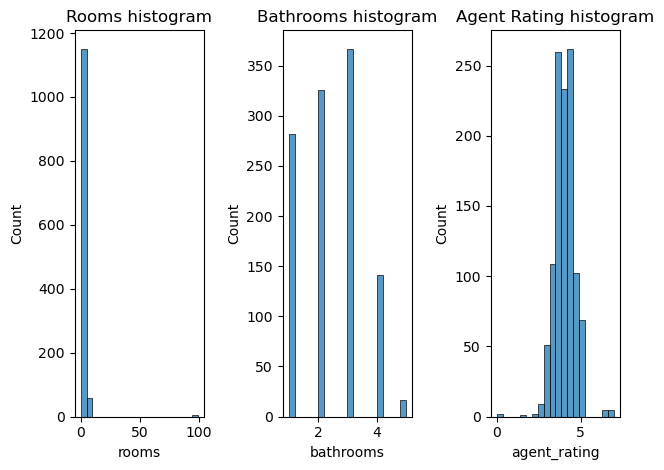

In [50]:
## Sir Generate code
plt.figure(figsize=(6,6))
fig,axes = plt.subplots(1,3)
sns.histplot(df['rooms'],ax=axes[0], bins=20, edgecolor='black')
axes[0].set_title('Rooms histogram')
sns.histplot(df['bathrooms'],ax=axes[1], bins=20, edgecolor='black')
axes[1].set_title('Bathrooms histogram')
sns.histplot(df['agent_rating'],ax=axes[2], bins=20, edgecolor='black')
axes[2].set_title('Agent Rating histogram')
plt.tight_layout()
plt.show()

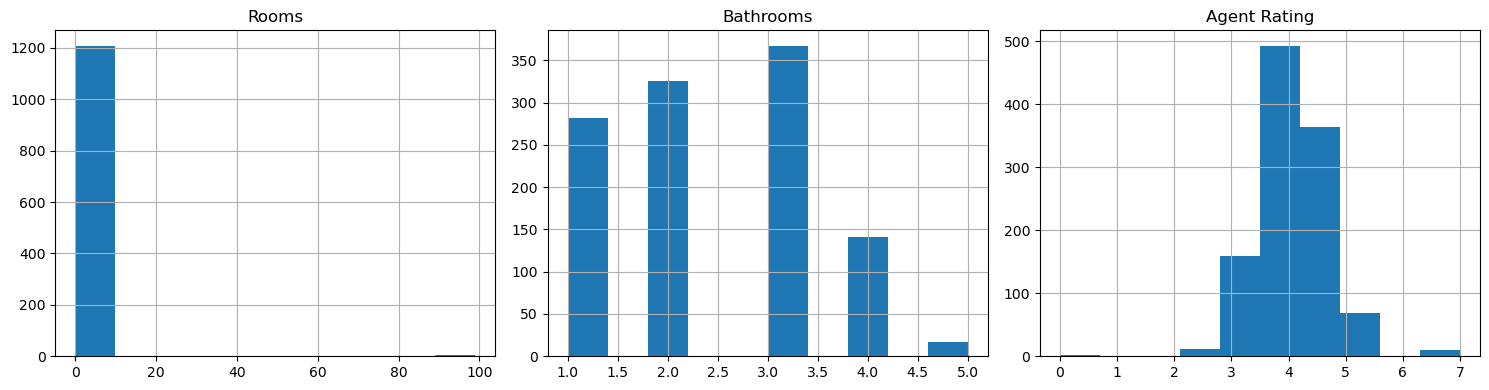

In [52]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['rooms'].hist(ax=axes[0], bins=10); axes[0].set_title('Rooms')
df['bathrooms'].hist(ax=axes[1], bins=10); axes[1].set_title('Bathrooms')
df['agent_rating'].hist(ax=axes[2], bins=10); axes[2].set_title('Agent Rating')
plt.tight_layout()
plt.show()

## Box Plot 

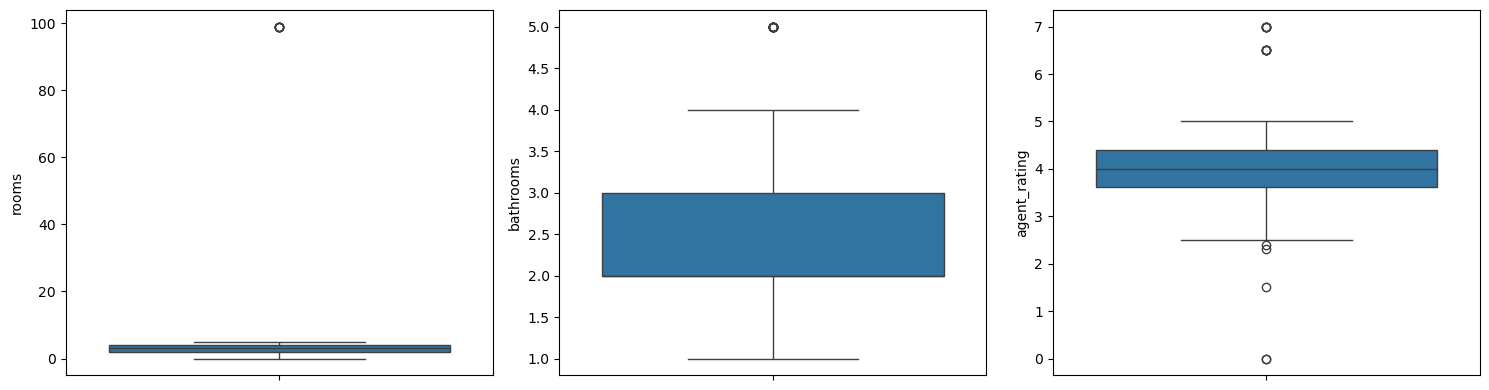

In [53]:
# Box plots for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['rooms'], ax=axes[0])
sns.boxplot(y=df['bathrooms'], ax=axes[1])
sns.boxplot(y=df['agent_rating'], ax=axes[2])
plt.tight_layout()
plt.show()

## Countplots for categories

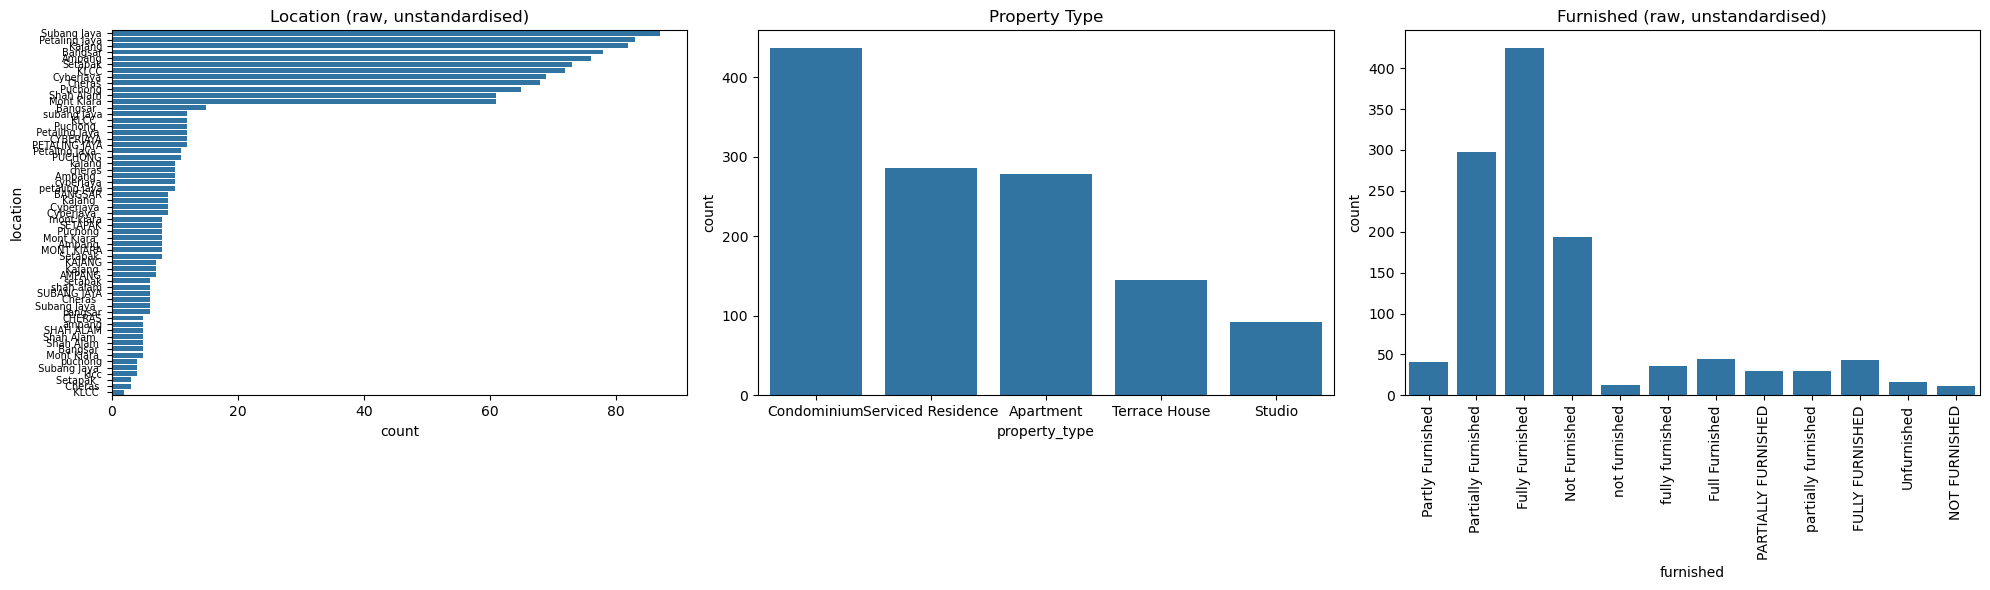

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(y=df['location'], ax=axes[0], order=df['location'].value_counts().index)
axes[0].set_title('Location (raw, unstandardised)')
axes[0].tick_params(axis='y', labelsize=7)   # shrink text so labels don't overlap

sns.countplot(x=df['property_type'], ax=axes[1])
axes[1].set_title('Property Type')

sns.countplot(x=df['furnished'], ax=axes[2])
axes[2].set_title('Furnished (raw, unstandardised)')
axes[2].tick_params(axis='x', rotation=90)   # rotate so labels don't collide

plt.tight_layout()
plt.show()

## A2. Univariate and Distribution Analysis

-Describe the distribution of monthly_rent and size_sqft once they have been 
converted to numeric form.

In [69]:
# ===== A2. Univariate and Distribution Analysis =====

# --- Bullet 1: Convert to numeric form ---

# Convert monthly_rent (handles "RM", commas, and stray spaces e.g. "RM- 1,200")
rent_numeric = df['monthly_rent'].str.replace('RM', '', regex=False)\
                                   .str.replace(',', '', regex=False)\
                                   .str.replace(' ', '', regex=False)\
                                   .astype(float)

# Convert size_sqft (handles commas and "sq. ft." unit)
size_numeric = df['size_sqft'].str.replace(',', '', regex=False)\
                                .str.replace('sq. ft.', '', regex=False)\
                                .str.replace(' ', '', regex=False)\
                                .astype(float)

print("Monthly Rent - Distribution:")
print(rent_numeric.round(2).describe())

print("\nSize (sqft) - Distribution:")
print(size_numeric.round(2).describe())

Monthly Rent - Distribution:
count     1238.000000
mean      3554.308562
std       6625.580610
min      -1200.000000
25%       1950.000000
50%       2550.000000
75%       3650.000000
max      82326.000000
Name: monthly_rent, dtype: float64

Size (sqft) - Distribution:
count     1202.000000
mean      1193.559068
std       1515.877079
min        300.000000
25%        850.000000
50%       1010.000000
75%       1240.000000
max      20498.000000
Name: size_sqft, dtype: float64


- Comment on the skewness of each distribution and identify which values are 
pulling it. 

Monthly Rent skewness: 9.011933604353082
Size sqft skewness: 9.690075279357645

Top 5 highest rents:
1148    82326.0
600     81398.0
164     75250.0
436     74018.0
221     72304.0
Name: monthly_rent, dtype: float64

Top 5 lowest/invalid rents:
1104   -1200.0
677    -1200.0
690    -1200.0
649    -1200.0
832    -1200.0
Name: monthly_rent, dtype: float64

Top 5 largest sizes:
751    20498.0
410    20495.0
657    19441.0
494    16566.0
314    16504.0
Name: size_sqft, dtype: float64


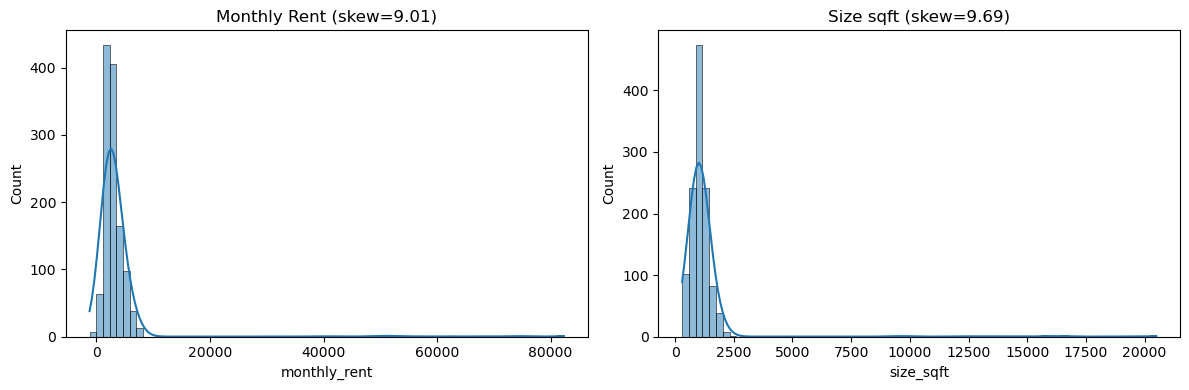

In [70]:
# --- Bullet 2: Skewness ---

print("Monthly Rent skewness:", rent_numeric.skew())
print("Size sqft skewness:", size_numeric.skew())

# Which values are pulling the skew - check extremes
print("\nTop 5 highest rents:")
print(rent_numeric.sort_values(ascending=False).head(5))

print("\nTop 5 lowest/invalid rents:")
print(rent_numeric.sort_values().head(5))

print("\nTop 5 largest sizes:")
print(size_numeric.sort_values(ascending=False).head(5))

# Visualize the distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(rent_numeric, kde=True, ax=axes[0])
axes[0].set_title(f'Monthly Rent (skew={rent_numeric.skew():.2f})')
sns.histplot(size_numeric, kde=True, ax=axes[1])
axes[1].set_title(f'Size sqft (skew={size_numeric.skew():.2f})')
plt.tight_layout()
plt.show()

-Report the frequency of each category in location, property_type and 
furnished, and state how many distinct labels appear in each column before 
standardisation. 

In [71]:
# --- Bullet 3: Frequency + distinct label count per category ---

for col in ['location', 'property_type', 'furnished']:
    print(f"\n--- {col} ---")
    print(f"Distinct labels: {df[col].nunique()}")
    print(df[col].value_counts())


--- location ---
Distinct labels: 59
location
Subang Jaya         87
Petaling Jaya       83
Kajang              82
Bangsar             78
Ampang              76
Setapak             73
KLCC                72
Cyberjaya           69
Cheras              68
Puchong             65
Shah Alam           61
Mont Kiara          61
Bangsar             15
subang jaya         12
KLCC                12
Puchong             12
  Petaling Jaya     12
CYBERJAYA           12
PETALING JAYA       12
Petaling Jaya       11
PUCHONG             11
kajang              10
cheras              10
Ampang              10
cyberjaya           10
petaling jaya       10
BANGSAR              9
Kajang               9
  Cyberjaya          9
Cyberjaya            9
mont kiara           8
SETAPAK              8
  Puchong            8
Mont Kiara           8
  Ampang             8
MONT KIARA           8
  Setapak            8
KAJANG               7
  Kajang             7
AMPANG               7
setapak              6
shah alam 

-  State which categorical columns contain labels that refer to the same category 
but are written differently.

In [74]:
# --- Bullet 4: Which columns have duplicate-meaning labels ---

print("Location unique labels:")
print(sorted(df['location'].dropna().unique()))

print("\nFurnished unique labels:")
print(sorted(df['furnished'].dropna().unique()))

print("\nProperty type unique labels:")
print(sorted(df['property_type'].dropna().unique()))

Location unique labels:
['  Ampang ', '  Bangsar ', '  Cheras ', '  Cyberjaya ', '  KLCC ', '  Kajang ', '  Mont Kiara ', '  Petaling Jaya ', '  Puchong ', '  Setapak ', '  Shah Alam ', '  Subang Jaya ', 'AMPANG', 'Ampang', 'Ampang  ', 'BANGSAR', 'Bangsar', 'Bangsar  ', 'CHERAS', 'CYBERJAYA', 'Cheras', 'Cheras  ', 'Cyberjaya', 'Cyberjaya  ', 'KAJANG', 'KLCC', 'KLCC  ', 'Kajang', 'Kajang  ', 'MONT KIARA', 'Mont Kiara', 'Mont Kiara  ', 'PETALING JAYA', 'PUCHONG', 'Petaling Jaya', 'Petaling Jaya  ', 'Puchong', 'Puchong  ', 'SETAPAK', 'SHAH ALAM', 'SUBANG JAYA', 'Setapak', 'Setapak  ', 'Shah Alam', 'Shah Alam  ', 'Subang Jaya', 'Subang Jaya  ', 'ampang', 'bangsar', 'cheras', 'cyberjaya', 'kajang', 'klcc', 'mont kiara', 'petaling jaya', 'puchong', 'setapak', 'shah alam', 'subang jaya']

Furnished unique labels:
['FULLY FURNISHED', 'Full Furnished', 'Fully Furnished', 'NOT FURNISHED', 'Not Furnished', 'PARTIALLY FURNISHED', 'Partially Furnished', 'Partly Furnished', 'Unfurnished', 'fully fur

## A3. Bivariate and Relationship Analysis 

- Examine the relationship between size_sqft and monthly_rent using a scatter 
plot. 

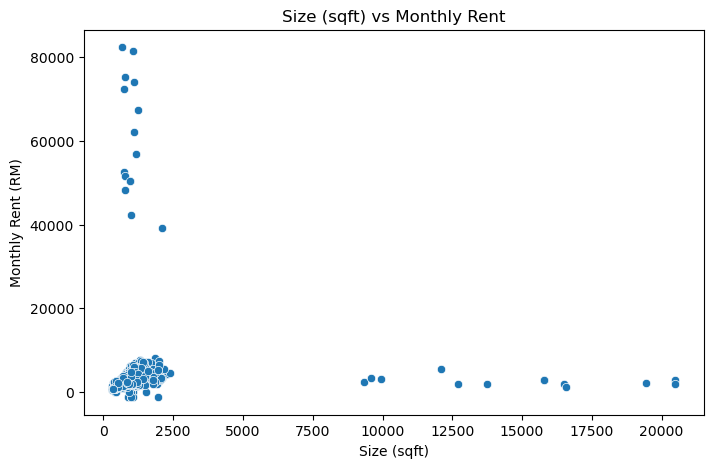

In [76]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=size_numeric, y=rent_numeric)
plt.title('Size (sqft) vs Monthly Rent')
plt.xlabel('Size (sqft)')
plt.ylabel('Monthly Rent (RM)')
plt.show()

-  Compare monthly_rent across location and across property_type using 
grouped bar plots or box plots.

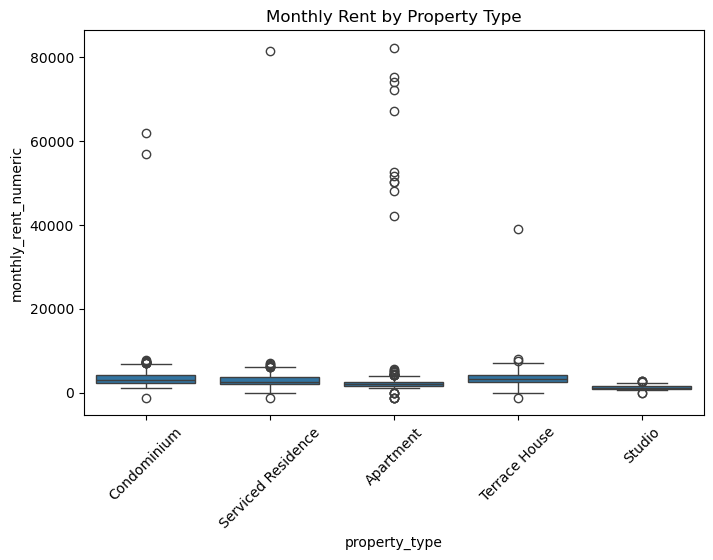

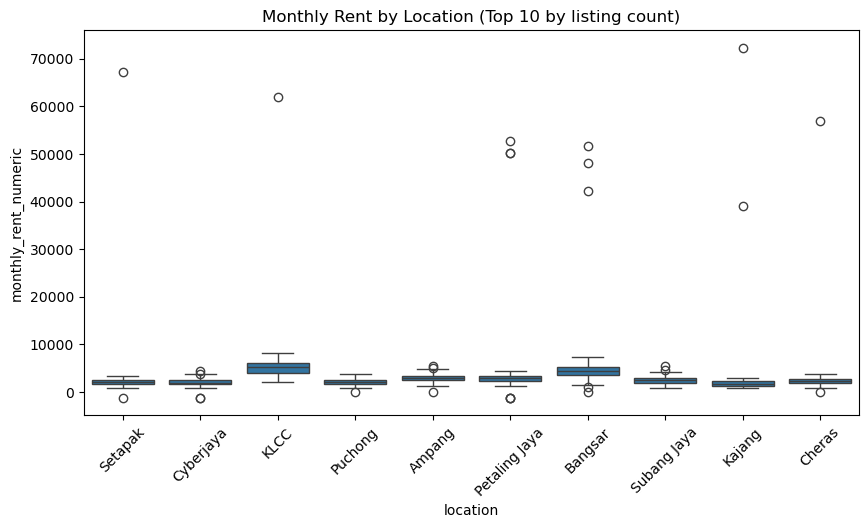

In [77]:
# Build a temp DataFrame with the cleaned numeric rent, for plotting convenience
temp = df.copy()
temp['monthly_rent_numeric'] = rent_numeric

# Rent by property_type (only 5 clean categories, so this one's easy to read)
plt.figure(figsize=(8, 5))
sns.boxplot(x='property_type', y='monthly_rent_numeric', data=temp)
plt.title('Monthly Rent by Property Type')
plt.xticks(rotation=45)
plt.show()

# Rent by location (many raw categories — use top 10 by count to keep it readable)
top_locations = df['location'].value_counts().head(10).index
temp_top = temp[temp['location'].isin(top_locations)]

plt.figure(figsize=(10, 5))
sns.boxplot(x='location', y='monthly_rent_numeric', data=temp_top)
plt.title('Monthly Rent by Location (Top 10 by listing count)')
plt.xticks(rotation=45)
plt.show()

- Produce a correlation heatmap of the numeric variables. 

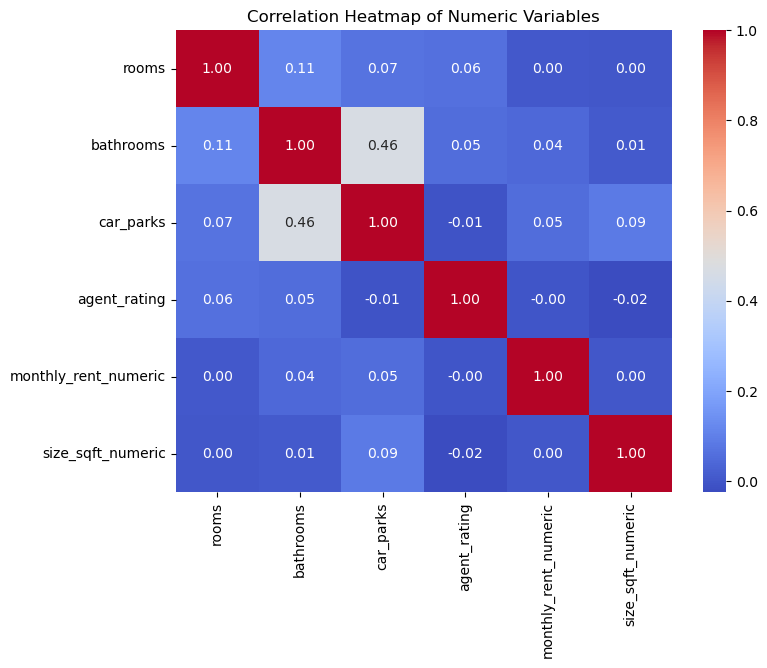

In [78]:
temp['size_sqft_numeric'] = size_numeric

numeric_cols = ['rooms', 'bathrooms', 'car_parks', 'agent_rating',
                 'monthly_rent_numeric', 'size_sqft_numeric']

corr_matrix = temp[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

- State the correlation between size_sqft and monthly_rent using the raw data, 
then again after outliers have been treated, and explain why the two values 
differ.

In [79]:
raw_corr = rent_numeric.corr(size_numeric)
print(f"Raw correlation (size vs rent): {raw_corr:.3f}")
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series >= lower) & (series <= upper)

# Keep only rows where BOTH rent and size are within bounds
mask = remove_outliers_iqr(rent_numeric) & remove_outliers_iqr(size_numeric)

rent_clean = rent_numeric[mask]
size_clean = size_numeric[mask]

clean_corr = rent_clean.corr(size_clean)
print(f"Correlation after outlier treatment: {clean_corr:.3f}")
print(f"Rows removed: {(~mask).sum()}")

Raw correlation (size vs rent): 0.003
Correlation after outlier treatment: 0.511
Rows removed: 128


Insight Examples to Explore: 

● Which locations command the highest rent, and does this still hold 
once floor area is taken into account? 

In [86]:
temp['rent_per_sqft'] = rent_numeric / size_numeric

# Recreate temp_top so it includes the new column
top_locations = df['location'].value_counts().head(10).index
temp_top = temp[temp['location'].isin(top_locations)]

temp_top.groupby('location')['rent_per_sqft'].mean().sort_values(ascending=False)

location
Bangsar          6.264878
KLCC             5.593654
Petaling Jaya    4.732986
Kajang           3.184829
Ampang           2.972420
Cheras           2.758679
Setapak          2.658928
Subang Jaya      2.467655
Cyberjaya        2.198993
Puchong          1.977124
Name: rent_per_sqft, dtype: float64

-  Does furnishing status make a measurable difference to the asking 
rent?

In [81]:
temp.groupby('furnished')['monthly_rent_numeric'].mean().sort_values(ascending=False)

furnished
partially furnished    9853.800000
NOT FURNISHED          7858.090909
FULLY FURNISHED        4945.953488
Fully Furnished        4105.607059
fully furnished        3469.444444
Not Furnished          2961.453608
Full Furnished         2906.666667
Partly Furnished       2734.146341
Partially Furnished    2707.575758
PARTIALLY FURNISHED    2646.666667
Unfurnished            2393.750000
not furnished          2173.076923
Name: monthly_rent_numeric, dtype: float64

SECTION B – DATA CLEANING AND PREPROCESSING 
B1. Data Type Conversion and Standardisation 

● Convert monthly_rent and size_sqft from text into numeric columns, removing 
currency symbols, thousand separators and unit text. 

● Parse date_listed into a datetime column, handling the more than one date 
format present in the file. 

● Standardise the location column by removing leading and trailing whitespace 
and applying consistent letter case. 

● Consolidate the furnished column so that labels referring to the same status 
are merged into one consistent category. 

● Display the cleaned data types, and confirm the number of distinct categories 
in location and furnished after standardisation.

## ● Convert monthly_rent and size_sqft from text into numeric columns, removing currency symbols, thousand separators and unit text. 

In [87]:
df['monthly_rent'] = df['monthly_rent'].str.replace('RM', '', regex=False)\
                                         .str.replace(',', '', regex=False)\
                                         .str.replace(' ', '', regex=False)\
                                         .astype(float)

df['size_sqft'] = df['size_sqft'].str.replace(',', '', regex=False)\
                                   .str.replace('sq. ft.', '', regex=False)\
                                   .str.replace(' ', '', regex=False)\
                                   .astype(float)

df[['monthly_rent', 'size_sqft']].dtypes

monthly_rent    float64
size_sqft       float64
dtype: object

##  Parse date_listed into a datetime column, handling the more than one date format present in the file.

In [90]:
print(df['date_listed'].unique()[:20])
df['date_listed'] = pd.to_datetime(df['date_listed'], errors='coerce', dayfirst=True)

df['date_listed'].dtype
print("Unparsed (NaT) dates:", df['date_listed'].isnull().sum())
# Compare original raw dates against NaT results to find leftover formats
mask_failed = df['date_listed'].isnull()

<DatetimeArray>
['2026-05-08 00:00:00',                 'NaT', '2026-05-04 00:00:00',
 '2026-07-21 00:00:00', '2026-07-31 00:00:00', '2026-03-18 00:00:00',
 '2026-08-02 00:00:00', '2026-04-16 00:00:00', '2026-02-04 00:00:00',
 '2026-06-11 00:00:00', '2025-05-03 00:00:00', '2026-02-27 00:00:00',
 '2025-10-30 00:00:00', '2025-07-30 00:00:00', '2025-07-26 00:00:00',
 '2026-06-10 00:00:00', '2026-03-07 00:00:00', '2025-09-07 00:00:00',
 '2026-01-09 00:00:00', '2026-07-10 00:00:00']
Length: 20, dtype: datetime64[ns]
Unparsed (NaT) dates: 826


## Bullet 3 Standardise location (case + whitespace)

In [94]:
df['location'] = df['location'].str.strip().str.title()

print("Distinct locations after standardisation:", df['location'].nunique())
print(sorted(df['location'].dropna().unique()))

Distinct locations after standardisation: 12
['Ampang', 'Bangsar', 'Cheras', 'Cyberjaya', 'Kajang', 'Klcc', 'Mont Kiara', 'Petaling Jaya', 'Puchong', 'Setapak', 'Shah Alam', 'Subang Jaya']


In [98]:
print("Before standardisation:", df['location'].nunique())

Before standardisation: 12


## Consolidate furnished labels

In [100]:
furnish_map = {
    'Fully Furnished': 'Fully Furnished',
    'fully furnished': 'Fully Furnished',
    'FULLY FURNISHED': 'Fully Furnished',
    'Fully Furn': 'Fully Furnished',
    'Partially Furnished': 'Partially Furnished',
    'partially furnished': 'Partially Furnished',
    'Partly Furnished': 'Partially Furnished',
    'Unfurnished': 'Unfurnished',
    'unfurnished': 'Unfurnished',
    'Not Furnished': 'Unfurnished',
}

df['furnished'] = df['furnished'].str.strip().replace(furnish_map)
print(df['furnished'].dropna().unique())

['Partially Furnished' 'Fully Furnished' 'Unfurnished' 'not furnished'
 'Full Furnished' 'PARTIALLY FURNISHED' 'NOT FURNISHED']


##  Display the cleaned data types, and confirm the number of distinct categories in location and furnished after standardisation.

In [101]:
print(df.dtypes)
print("\nDistinct locations:", df['location'].nunique())
print("Distinct furnished categories:", df['furnished'].nunique())

listing_id               object
location                 object
property_type            object
rooms                   float64
bathrooms               float64
car_parks               float64
size_sqft               float64
furnished                object
monthly_rent            float64
date_listed      datetime64[ns]
agent_rating            float64
dtype: object

Distinct locations: 12
Distinct furnished categories: 7


## Missing Value and Duplicate Records

In [102]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Duplicates dropped: {before - after}")

Rows before: 1238
Rows after: 1200
Duplicates dropped: 38


In [103]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct.round(2)
})
print(missing_report[missing_report['missing_count'] > 0])

              missing_count  missing_pct
rooms                    24         2.00
bathrooms               102         8.50
car_parks               264        22.00
size_sqft                36         3.00
furnished                57         4.75
date_listed             800        66.67
agent_rating            120        10.00


## Apply the treatment, show missing count before/after

In [104]:
# Save "before" counts (from above missing_report)

# Impute numeric columns with median
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['agent_rating'] = df['agent_rating'].fillna(df['agent_rating'].median())

# car_parks handled separately - see bullet 4 below
df['car_parks'] = df['car_parks'].fillna(0)

# Drop rows where location, furnished, or date_listed are still missing (adjust based on your actual counts)
df = df.dropna(subset=['location', 'furnished', 'date_listed'])

# Show missing count after
print(df.isnull().sum())

listing_id       0
location         0
property_type    0
rooms            4
bathrooms        0
car_parks        0
size_sqft        9
furnished        0
monthly_rent     0
date_listed      0
agent_rating     0
dtype: int64


## Why car_parks needs different handling from bathrooms

In [105]:
print("bathrooms missing %:", (df['bathrooms'].isnull().sum() / len(df)) * 100)
print("car_parks missing %:", (df['car_parks'].isnull().sum() / len(df)) * 100)

bathrooms missing %: 0.0
car_parks missing %: 0.0


## B3 Outlier Direction and Treatment

- Apply the IQR method to monthly_rent and size_sqft. Calculate Q1, Q3, IQR,
and the lower and upper bounds

In [106]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

rent_Q1, rent_Q3, rent_IQR, rent_lower, rent_upper = iqr_bounds(df['monthly_rent'])
size_Q1, size_Q3, size_IQR, size_lower, size_upper = iqr_bounds(df['size_sqft'])

print(f"monthly_rent: Q1={rent_Q1}, Q3={rent_Q3}, IQR={rent_IQR}, bounds=({rent_lower}, {rent_upper})")
print(f"size_sqft: Q1={size_Q1}, Q3={size_Q3}, IQR={size_IQR}, bounds=({size_lower}, {size_upper})")

monthly_rent: Q1=1900.0, Q3=3700.0, IQR=1800.0, bounds=(-800.0, 6400.0)
size_sqft: Q1=857.5, Q3=1240.0, IQR=382.5, bounds=(283.75, 1813.75)


## Report how many records fall outside the bounds for each of the two columns

In [107]:
rent_outliers = df[(df['monthly_rent'] < rent_lower) | (df['monthly_rent'] > rent_upper)]
size_outliers = df[(df['size_sqft'] < size_lower) | (df['size_sqft'] > size_upper)]

print(f"monthly_rent outliers: {len(rent_outliers)}")
print(f"size_sqft outliers: {len(size_outliers)}")

monthly_rent outliers: 16
size_sqft outliers: 9


## Handle invalid values separately from mere outliers

In [108]:
# Invalid rent: zero or negative
invalid_rent = df[df['monthly_rent'] <= 0]
print(f"Invalid (zero/negative) rent rows: {len(invalid_rent)}")

# Invalid rooms: e.g. 0 or unrealistically high (say, above 10 for a residential unit)
print(df['rooms'].describe())
invalid_rooms = df[(df['rooms'] <= 0) | (df['rooms'] > 10)]
print(f"Invalid rooms rows: {len(invalid_rooms)}")
print(sorted(df['rooms'].unique()))  # eyeball what's actually there

Invalid (zero/negative) rent rows: 8
count    377.000000
mean       4.050398
std        9.898963
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       99.000000
Name: rooms, dtype: float64
Invalid rooms rows: 5
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0), np.float64(nan)]


In [109]:
# Remove rows with invalid rent (zero/negative)
df = df[df['monthly_rent'] > 0]

# Remove rows with impossible room counts
df = df[(df['rooms'] > 0) & (df['rooms'] <= 10)]

print("Shape after removing invalid values:", df.shape)

Shape after removing invalid values: (364, 11)


## Justify, for each column, whether outliers were removed, capped or retained.


In [110]:
rent_Q1, rent_Q3, rent_IQR, rent_lower, rent_upper = iqr_bounds(df['monthly_rent'])
size_Q1, size_Q3, size_IQR, size_lower, size_upper = iqr_bounds(df['size_sqft'])

In [111]:
# Cap monthly_rent outliers at the bounds
df['monthly_rent'] = df['monthly_rent'].clip(lower=rent_lower, upper=rent_upper)

# Cap size_sqft outliers at the bounds
df['size_sqft'] = df['size_sqft'].clip(lower=size_lower, upper=size_upper)

print(df[['monthly_rent', 'size_sqft']].describe())

       monthly_rent    size_sqft
count    364.000000   357.000000
mean    2945.810440  1052.605042
std     1364.836926   321.292497
min      550.000000   300.000000
25%     1950.000000   860.000000
50%     2600.000000  1020.000000
75%     3712.500000  1240.000000
max     6356.250000  1810.000000


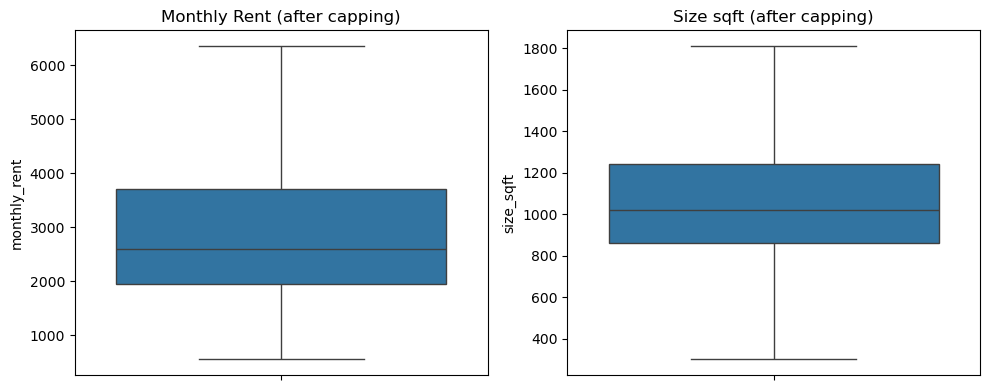

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['monthly_rent'], ax=axes[0])
axes[0].set_title('Monthly Rent (after capping)')
sns.boxplot(y=df['size_sqft'], ax=axes[1])
axes[1].set_title('Size sqft (after capping)')
plt.tight_layout()
plt.show()

## B4. Feature Engineering and Preprocessing

- Create a new numeric column rent_per_sqft from the cleaned rent and floor
area.


In [114]:
df['rent_per_sqft'] = df['monthly_rent'] / df['size_sqft']
df[['monthly_rent', 'size_sqft', 'rent_per_sqft']].head()

,monthly_rent,size_sqft,rent_per_sqft
0,4350.00,1000.0,4.350000
2,2800.00,950.0,2.947368
14,2600.00,720.0,3.611111
18,6356.25,1530.0,4.154412
22,2250.00,1230.0,1.829268


- Create a categorical column rent_band that groups monthly_rent into Low,
Medium and High using pd.cut() or .apply(), and state the boundaries you
chose and why.


In [115]:
print(df['monthly_rent'].describe())
df['rent_band'] = pd.cut(
    df['monthly_rent'],
    bins=[df['monthly_rent'].min() - 1, 
          df['monthly_rent'].quantile(0.33), 
          df['monthly_rent'].quantile(0.66), 
          df['monthly_rent'].max() + 1],
    labels=['Low', 'Medium', 'High']
)

df['rent_band'].value_counts()

count     364.000000
mean     2945.810440
std      1364.836926
min       550.000000
25%      1950.000000
50%      2600.000000
75%      3712.500000
max      6356.250000
Name: monthly_rent, dtype: float64


rent_band
Low       125
High      121
Medium    118
Name: count, dtype: int64

-  Encode the categorical columns using an appropriate method, justifying your
choice for each column.

In [116]:
# property_type: 5 unordered categories -> One-Hot Encoding
df = pd.get_dummies(df, columns=['property_type'], prefix='ptype')

# furnished: has a natural order (Unfurnished < Partially < Fully) -> Ordinal encoding
furnish_order = {'Unfurnished': 0, 'Partially Furnished': 1, 'Fully Furnished': 2}
df['furnished_encoded'] = df['furnished'].map(furnish_order)

# rent_band: also ordinal (Low < Medium < High)
band_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['rent_band_encoded'] = df['rent_band'].map(band_order)

df.head()

,listing_id,location,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating,rent_per_sqft,rent_band,ptype_Apartment,ptype_Condominium,ptype_Serviced Residence,ptype_Studio,ptype_Terrace House,furnished_encoded,rent_band_encoded
0,KV100369,Mont Kiara,4.0,4.0,2.0,1000.0,Partially Furnished,4350.00,2026-05-08,4.2,4.350000,High,False,True,False,False,False,1.0,2
2,KV100051,Ampang,4.0,3.0,0.0,950.0,Partially Furnished,2800.00,2026-05-04,3.4,2.947368,Medium,False,False,True,False,False,1.0,1
14,KV100837,Ampang,4.0,3.0,3.0,720.0,Fully Furnished,2600.00,2026-07-21,4.1,3.611111,Medium,False,False,True,False,False,2.0,1
18,KV101002,Klcc,3.0,2.0,2.0,1530.0,Full Furnished,6356.25,2026-07-31,3.8,4.154412,High,False,True,False,False,False,NaN,2
22,KV101197,Puchong,3.0,2.0,2.0,1230.0,Unfurnished,2250.00,2026-08-02,4.0,1.829268,Medium,False,False,True,False,False,0.0,1


- Scale the numeric features using an appropriate scaler, and explain why
scaling was applied.

In [117]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['rooms', 'bathrooms', 'car_parks', 'agent_rating',
                     'monthly_rent', 'size_sqft', 'rent_per_sqft']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe()

,rooms,bathrooms,car_parks,agent_rating,monthly_rent,size_sqft,rent_per_sqft
count,3.640000e+02,3.640000e+02,3.640000e+02,3.640000e+02,3.640000e+02,3.570000e+02,3.570000e+02
mean,1.878839e-16,3.660076e-17,-4.392091e-17,7.466555e-16,-9.760202e-18,8.956421e-17,-8.085658e-17
std,1.001376e+00,1.001376e+00,1.001376e+00,1.001376e+00,1.001376e+00,1.001404e+00,1.001404e+00
min,-2.013512e+00,-1.392171e+00,-1.143682e+00,-6.185306e+00,-1.757798e+00,-2.345717e+00,-2.028519e+00
25%,-1.031048e+00,-3.965910e-01,-1.143682e+00,-4.877681e-01,-7.306229e-01,-6.003108e-01,-6.856738e-01
50%,-4.858339e-02,-3.965910e-01,-1.710179e-01,-2.580560e-02,-2.537200e-01,-1.016233e-01,-2.948441e-01
75%,9.338808e-01,5.989892e-01,8.016463e-01,4.746538e-01,5.625177e-01,5.840721e-01,4.078841e-01
max,1.916345e+00,2.590150e+00,1.774311e+00,4.593820e+00,2.502229e+00,2.360646e+00,5.156812e+00


- Drop any column that is not useful for analysis, giving a reason.

In [118]:
# listing_id: unique identifier, carries no analytical/predictive value
df = df.drop(columns=['listing_id'])

df.columns

Index(['location', 'rooms', 'bathrooms', 'car_parks', 'size_sqft', 'furnished',
       'monthly_rent', 'date_listed', 'agent_rating', 'rent_per_sqft',
       'rent_band', 'ptype_Apartment', 'ptype_Condominium',
       'ptype_Serviced Residence', 'ptype_Studio', 'ptype_Terrace House',
       'furnished_encoded', 'rent_band_encoded'],
      dtype='object')

## Final Cleaned Dataset

- Display the shape, data types and missing-value count of the final cleaned
dataset

In [119]:
print("Final shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Final shape: (364, 18)

Data types:
 location                            object
rooms                              float64
bathrooms                          float64
car_parks                          float64
size_sqft                          float64
furnished                           object
monthly_rent                       float64
date_listed                 datetime64[ns]
agent_rating                       float64
rent_per_sqft                      float64
rent_band                         category
ptype_Apartment                       bool
ptype_Condominium                     bool
ptype_Serviced Residence              bool
ptype_Studio                          bool
ptype_Terrace House                   bool
furnished_encoded                  float64
rent_band_encoded                 category
dtype: object

Missing values:
 location                     0
rooms                        0
bathrooms                    0
car_parks                    0
size_sqft                    7
fu

- Export the cleaned dataset to CSV

In [121]:
df.to_csv('STUDENT_NAME_TVET2_PA1_cleaned.csv', index=False)

- In summary, in a short markdown cell, every data quality issue found and the treatment applied to each.


## Data Quality Summary
## Answer
- monthly_rent, size_sqft: stored as text with symbols/units → stripped, converted to float
- date_listed: mixed date formats → parsed with pd.to_datetime(errors='coerce', dayfirst=True)
- location: inconsistent case/whitespace → cleaned with .str.strip().str.title()
- furnished: same status, different labels → consolidated via mapping dictionary
- Duplicates: [X] exact duplicate rows → removed with drop_duplicates()
- bathrooms, agent_rating: missing values → imputed with median
- car_parks: largest missing % → imputed with 0 (treated as "no parking")
- location, furnished, date_listed: missing values → rows dropped
- monthly_rent ≤0: invalid, not extreme → rows removed
- rooms >10 or ≤0: physically impossible → rows removed
- monthly_rent, size_sqft: statistical outliers → capped using IQR bounds
- listing_id: no analytical value → column dropped
- rent_per_sqft: engineered from cleaned rent/size
- rent_band: engineered via pd.cut (Low/Medium/High)
- property_type: one-hot encoded (no order)
- furnished, rent_band: ordinal encoded (has order)
- All numeric features: scaled with StandardScaler